In [2]:
from macrodata_tools.data import get_cpi, compute_inflation
import matplotlib.pyplot as plt

/Users/dhruvisachdeva/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
cpi = get_cpi()
inflation = compute_inflation(cpi)

inflation = inflation.dropna()

inflation.head()

,Inflation
DATE,
2001-01-01,3.721205
2001-02-01,3.529412
2001-03-01,2.982456
2001-04-01,3.218256
2001-05-01,3.563084


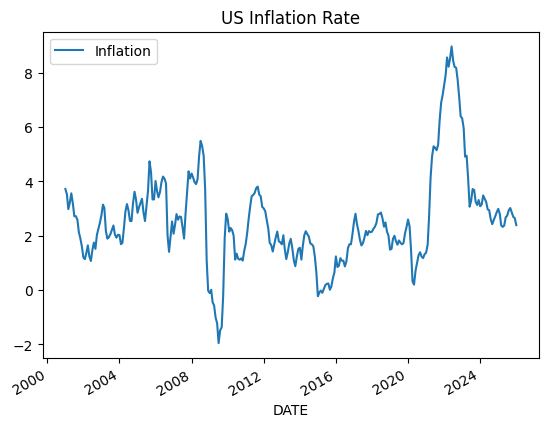

In [4]:
inflation.plot(title="US Inflation Rate")
plt.show()

## Data Cleaning
Remove missing values and inspect structure

In [5]:
inflation = inflation.dropna()

print(inflation.head())
print(inflation.info())

            Inflation
DATE                 
2001-01-01   3.721205
2001-02-01   3.529412
2001-03-01   2.982456
2001-04-01   3.218256
2001-05-01   3.563084
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 300 entries, 2001-01-01 to 2026-01-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Inflation  300 non-null    float64
dtypes: float64(1)
memory usage: 4.7 KB
None


## Descriptive Statistics
Summary statistics of inflation

In [ ]:
inflation.describe()

In [ ]:
import numpy as np

mean_inflation = np.mean(inflation["Inflation"])
std_inflation = np.std(inflation["Inflation"])

print("Mean inflation:", mean_inflation)
print("Std inflation:", std_inflation)

Rolling Inflation

In [ ]:
inflation["Rolling_12M"] = inflation["Inflation"].rolling(window=12).mean()

inflation.head()

In [ ]:
import seaborn as sns

Distribution of Inflation

In [ ]:
sns.histplot(inflation["Inflation"], kde=True)
plt.title("Distribution of Inflation")
plt.show()

Time Series Visualization

In [ ]:
plt.figure(figsize=(10,5))

sns.lineplot(data=inflation, x=inflation.index, y="Inflation", label="Inflation")

sns.lineplot(data=inflation, x=inflation.index, y="Rolling_12M", label="12M Rolling Avg")

plt.title("US Inflation Over Time")
plt.xlabel("Year")
plt.ylabel("Inflation Rate")
plt.show()

Identify High Inflation Periods

In [ ]:
inflation["High_Inflation"] = inflation["Inflation"] > 5

inflation[inflation["High_Inflation"]].head()

Yearly Inflation Analysis

In [ ]:
yearly_inflation = inflation.resample("Y").mean()

yearly_inflation.head()

In [ ]:
yearly_inflation.plot(title="Average Yearly Inflation")
plt.show()